<center>
<img src="https://supportvectors.ai/logo-poster-transparent.png" width="400px" style="opacity:0.7">
</center>

In [1]:
%run supportvectors-common.ipynb


<div style="color:#aaa;font-size:8pt">
<hr/>
&copy; SupportVectors. All rights reserved. <blockquote>This notebook is the intellectual property of SupportVectors, and part of its training material. 
Only the participants in SupportVectors workshops are allowed to study the notebooks for educational purposes currently, but is prohibited from copying or using it for any other purposes without written permission.

<b> These notebooks are chapters and sections from Asif Qamar's textbook that he is writing on Data Science. So we request you to not circulate the material to others.</b>
 </blockquote>
 <hr/>
</div>



## ColPali multi-vector retrieval over PDF pages

This notebook walks through a **late-interaction** retrieval pipeline for document images:

1. Render each page of `AncientIndia.pdf` as an image.
2. Encode pages and queries with **ColQwen3** (`TomoroAI/tomoro-colqwen3-embed-4b`) via the SupportVectors cluster embedding API.
3. Store page multi-vectors in **Qdrant** with **MaxSim** scoring.
4. Run a text query, rank pages, and **highlight image patches** that contribute most to the MaxSim score.

ColPali-style models produce a matrix of token embeddings per page (one row per visual patch) and per query (one row per text token). Retrieval compares them with **MaxSim**: for each query token, take the best-matching page patch, then sum those scores.

### Configuration

In [1]:
import base64
import os
from pathlib import Path
from urllib.parse import unquote, urlparse

import fitz  # PyMuPDF
import matplotlib.pyplot as plt
import numpy as np
import requests
from IPython.display import Image as IPyImage, display
from PIL import Image
from qdrant_client import QdrantClient, models

# --- paths & service endpoints ---
NOTEBOOK_DIR = Path(".").resolve()
PDF_PATH = NOTEBOOK_DIR / "AncientIndia.pdf"
PAGE_IMAGE_DIR = NOTEBOOK_DIR / "_colpali_page_images"
PAGE_IMAGE_DIR.mkdir(exist_ok=True)

COLPALI_MODEL = "TomoroAI/tomoro-colqwen3-embed-4b"
EMBEDDING_DIM = 320  # ColQwen3 output dimension

QDRANT_HOST = os.environ.get("QDRANT_HOST", "10.0.10.65")
QDRANT_PORT = int(os.environ.get("QDRANT_PORT", "6333"))
COLLECTION_NAME = "ancient_india_colpali"

EMBED_BASE_URL = os.environ.get("EMBED_BASE_URL", "http://10.0.10.51:8000")
EMBED_IMAGE_MULTIVECTOR_URL = f"{EMBED_BASE_URL}/embed-image/v1/multivector-embeddings"

# Set to True to drop and recreate the collection on each run
RECREATE_COLLECTION = True

# ColPali page vectors are large (~6 MB JSON each); stay under Qdrant's 32 MB request limit
QDRANT_UPSERT_BATCH_SIZE = 4

Matplotlib is building the font cache; this may take a moment.


### ColPali embedding helpers

The functions below call the cluster **multivector image embedding** endpoint, which accepts base64-encoded images and plain-text queries in the same batch.

In [3]:
def _is_http_url(image_source: str) -> bool:
    parsed = urlparse(image_source)
    return parsed.scheme in {"http", "https"}


def _convert_image_to_base64(image_source: str) -> str:
  """Load an image from a URL or local path and return base64 bytes."""
  if _is_http_url(image_source):
    response = requests.get(image_source, timeout=30)
    response.raise_for_status()
    image_bytes = response.content
  else:
    parsed = urlparse(image_source)
    file_path = unquote(parsed.path) if parsed.scheme == "file" else image_source
    file_path = str(Path(file_path).resolve())
    with open(file_path, "rb") as image_file:
      image_bytes = image_file.read()
  return base64.b64encode(image_bytes).decode("utf-8")


def embed_colpali(
  data_images: list[str],
  data_texts: list[str],
  model_name: str = COLPALI_MODEL,
  batch_size: int = 8,
) -> list[list[list[float]]]:
  """Return per-input token embeddings ordered as [images…, texts…]."""
  base64_images = [_convert_image_to_base64(path) for path in data_images]
  data_inputs = base64_images + data_texts
  embeddings: list[list[list[float]]] = []

  for start in range(0, len(data_inputs), batch_size):
    batch = data_inputs[start : start + batch_size]
    response = requests.post(
      EMBED_IMAGE_MULTIVECTOR_URL,
      json={"model": model_name, "input_type": "auto", "input": batch},
      timeout=120,
    )
    response.raise_for_status()
    batch_embeddings = [item["embedding"] for item in response.json()["data"]]
    embeddings.extend(batch_embeddings)
    print(f"Embedded items {start}–{start + len(batch) - 1}")

  return embeddings


def embed_colpali_pages(page_paths: list[str]) -> list[list[list[float]]]:
  return embed_colpali(page_paths, [])


def embed_colpali_query(query: str) -> list[list[float]]:
  return embed_colpali([], [query])[0]

### Step 1 — Render PDF pages as images

Each PDF page becomes one **document** in the index. ColPali operates on page images, not extracted text.

Rendered 8 pages from AncientIndia.pdf


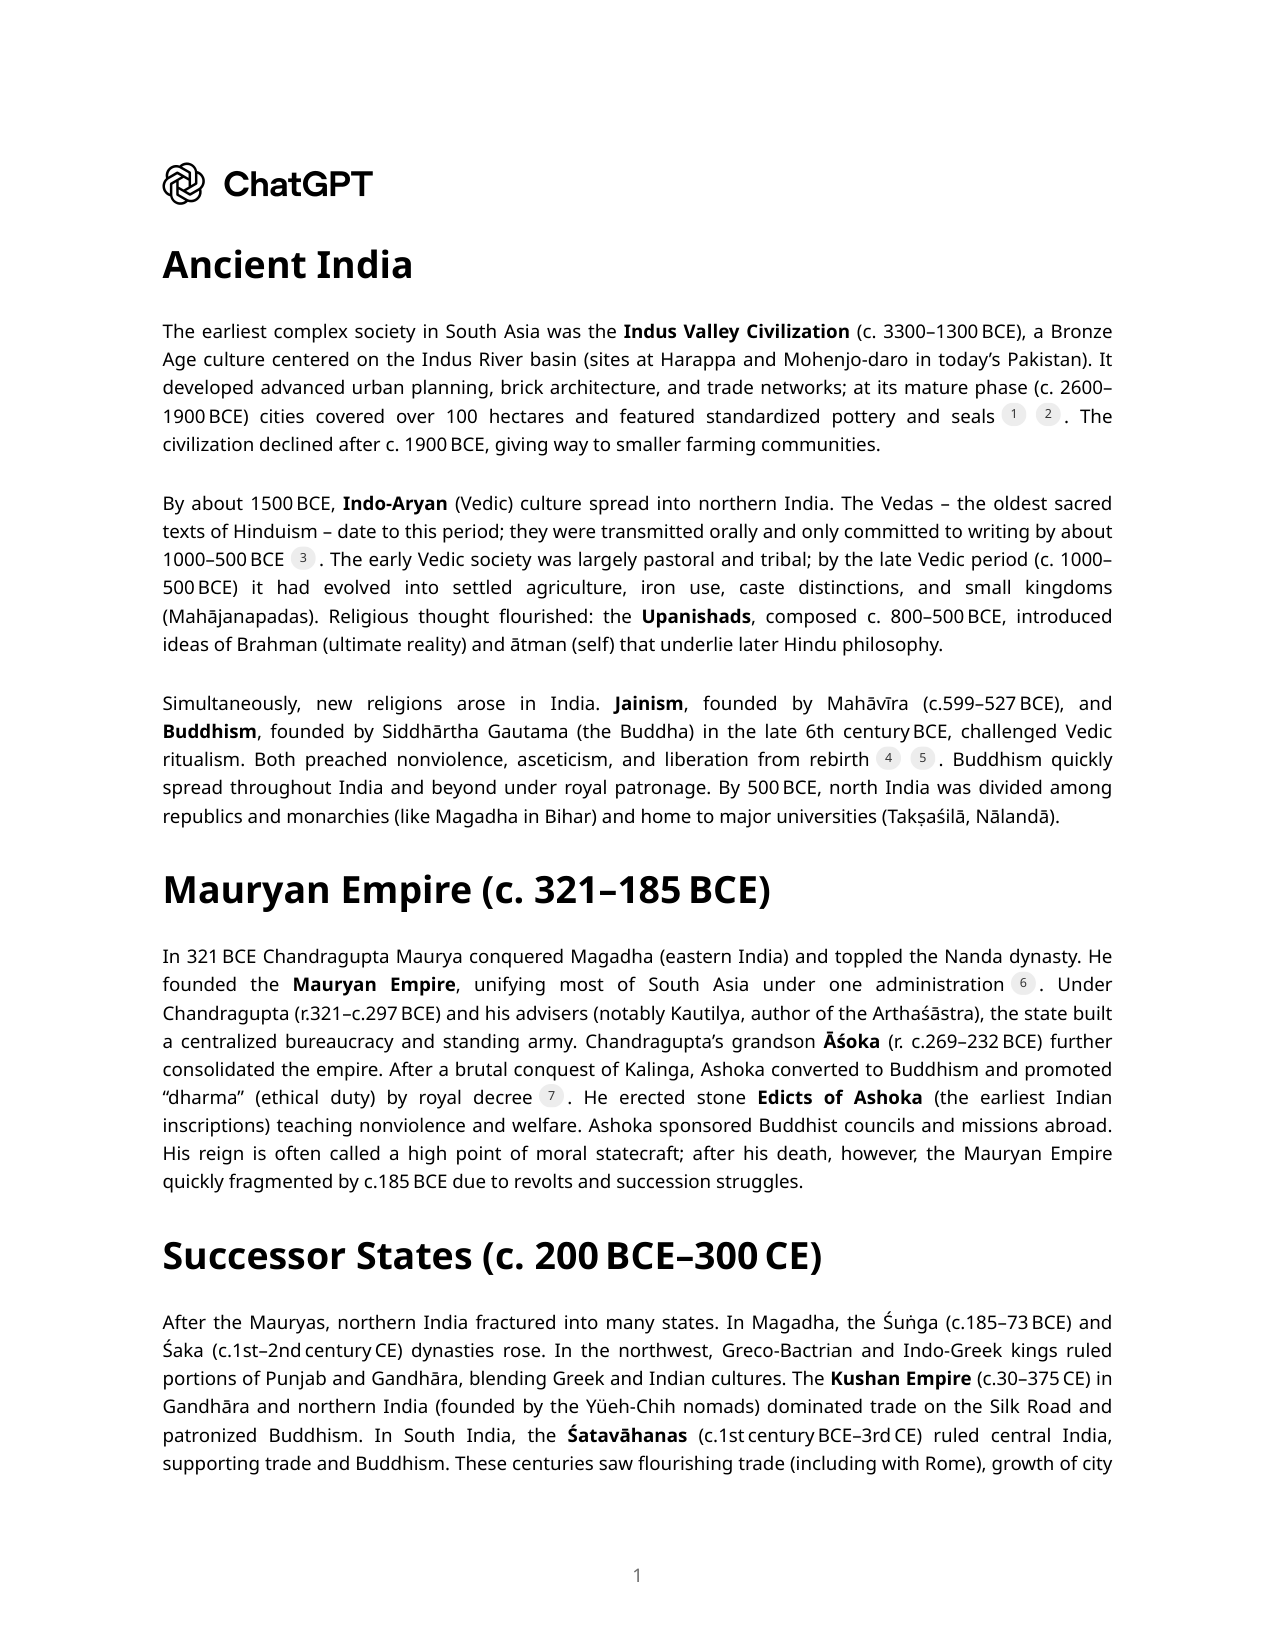

In [4]:
def pdf_to_page_images(pdf_path: Path, output_dir: Path, dpi: int = 150) -> list[Path]:
  """Render every PDF page to a PNG file and return the paths."""
  output_dir.mkdir(parents=True, exist_ok=True)
  doc = fitz.open(pdf_path)
  page_paths: list[Path] = []

  zoom = dpi / 72
  matrix = fitz.Matrix(zoom, zoom)

  for page_idx in range(len(doc)):
    page = doc.load_page(page_idx)
    pix = page.get_pixmap(matrix=matrix, alpha=False)
    image_path = output_dir / f"page_{page_idx + 1:03d}.png"
    pix.save(image_path)
    page_paths.append(image_path)

  doc.close()
  print(f"Rendered {len(page_paths)} pages from {pdf_path.name}")
  return page_paths


page_image_paths = pdf_to_page_images(PDF_PATH, PAGE_IMAGE_DIR)

# Preview the first page
display(IPyImage(filename=str(page_image_paths[0]), width=500))

### Step 2 — Encode pages and index in Qdrant

Qdrant's **multivector** collections store a matrix per point. Set the comparator to `MAX_SIM` so search uses late interaction (same scoring as ColPali / ColBERT).

In [5]:
qdrant = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)

if RECREATE_COLLECTION and qdrant.collection_exists(COLLECTION_NAME):
  qdrant.delete_collection(COLLECTION_NAME)

if not qdrant.collection_exists(COLLECTION_NAME):
  qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=models.VectorParams(
      size=EMBEDDING_DIM,
      distance=models.Distance.COSINE,
      multivector_config=models.MultiVectorConfig(
        comparator=models.MultiVectorComparator.MAX_SIM,
      ),
    ),
  )
  print(f"Created collection '{COLLECTION_NAME}'")

page_embeddings = embed_colpali_pages([str(p) for p in page_image_paths])
print(
  f"Example page embedding: {len(page_embeddings[0])} tokens × "
  f"{len(page_embeddings[0][0])} dims"
)

points = [
  models.PointStruct(
    id=page_idx,
    vector=embedding,
    payload={
      "source_pdf": PDF_PATH.name,
      "page_number": page_idx + 1,
      "image_path": str(page_image_paths[page_idx]),
      "model": COLPALI_MODEL,
      "num_tokens": len(embedding),
    },
  )
  for page_idx, embedding in enumerate(page_embeddings)
]

# Upsert in batches — a single request with all pages exceeds Qdrant's 32 MB payload limit
for start in range(0, len(points), QDRANT_UPSERT_BATCH_SIZE):
  batch = points[start : start + QDRANT_UPSERT_BATCH_SIZE]
  qdrant.upsert(collection_name=COLLECTION_NAME, points=batch)
  end = start + len(batch) - 1
  print(f"Upserted pages {start + 1}–{end + 1}")

print(f"Indexed {len(points)} pages in Qdrant at {QDRANT_HOST}:{QDRANT_PORT}")

Created collection 'ancient_india_colpali'
Embedded items 0–7
Example page embedding: 1251 tokens × 320 dims
Upserted pages 1–4
Upserted pages 5–8
Indexed 8 pages in Qdrant at 10.0.10.65:6333


### Step 3 — Query with MaxSim retrieval

Embed the query as a multi-vector, then ask Qdrant to rank pages by **MaxSim** against stored page embeddings.

In [6]:
QUERY = "Who was Ashoka and what did he do after the Kalinga war?"

query_embedding = embed_colpali_query(QUERY)
print(f"Query embedding: {len(query_embedding)} tokens × {len(query_embedding[0])} dims")

search_results = qdrant.query_points(
  collection_name=COLLECTION_NAME,
  query=query_embedding,
  limit=3,
  with_payload=True,
).points

for rank, hit in enumerate(search_results, start=1):
  print(
    f"#{rank}  page {hit.payload['page_number']}  "
    f"score={hit.score:.3f}  tokens={hit.payload['num_tokens']}"
  )

Embedded items 0–0
Query embedding: 26 tokens × 320 dims
#1  page 1  score=16.173  tokens=1251
#2  page 7  score=14.435  tokens=1251
#3  page 6  score=13.713  tokens=1251


### Step 4 — Highlight patches that drive the MaxSim score

MaxSim picks, for **each query token**, the single best-matching **visual patch** on the page, then sums those scores.

A page embedding is **not** all image patches — ColQwen3 prepends/appends a short vision prompt (~11 tokens) around **1240 spatial patches** arranged in a **31×40 grid** for our rendered pages.

We load only the ColQwen3 **processor** (not the 4B weights) to recover the image-token mask and patch grid, then show two views:

1. **Overlay** — heatmap on the page image (where on the page matched).
2. **Patch grid + scale** — the raw 31×40 score map with a colorbar (how strong each patch matched).

In [7]:
from transformers import AutoProcessor

colqwen_processor = AutoProcessor.from_pretrained(
  COLPALI_MODEL,
  trust_remote_code=True,
  max_num_visual_tokens=1280,
)


def _l2_normalize(matrix: np.ndarray) -> np.ndarray:
  norms = np.linalg.norm(matrix, axis=1, keepdims=True)
  return matrix / np.clip(norms, 1e-12, None)


def maxsim_similarity_matrix(
  query_vectors: list[list[float]],
  page_vectors: list[list[float]],
) -> np.ndarray:
  """Cosine similarity matrix with shape (n_query_tokens, n_page_tokens)."""
  q = _l2_normalize(np.asarray(query_vectors, dtype=np.float32))
  d = _l2_normalize(np.asarray(page_vectors, dtype=np.float32))
  return q @ d.T


def maxsim_score(sim_matrix: np.ndarray) -> float:
  """Sum over query tokens of their best patch match (ColPali MaxSim)."""
  return float(sim_matrix.max(axis=1).sum())


def _visual_patch_layout(image: Image.Image) -> tuple[np.ndarray, int, int]:
  """Return image-token mask and patch grid size (cols, rows) for ColQwen3."""
  batch = colqwen_processor.process_images(images=[image])
  image_mask = colqwen_processor.get_image_mask(batch)[0].cpu().numpy().astype(bool)
  merge_size = (
    colqwen_processor.image_processor.merge_size
    or colqwen_processor.image_processor.spatial_merge_size
  )
  n_patches_x, n_patches_y = colqwen_processor.get_n_patches(image.size, merge_size)
  return image_mask, n_patches_x, n_patches_y


def prepare_maxsim_visualization(
  image_path: str,
  query_vectors: list[list[float]],
  page_vectors: list[list[float]],
) -> dict:
  """Build overlay + patch-grid data for a query/page pair."""
  image = Image.open(image_path).convert("RGB")
  image_mask, n_patches_x, n_patches_y = _visual_patch_layout(image)

  n_visual = int(image_mask.sum())
  expected = n_patches_x * n_patches_y
  if n_visual != expected:
    raise ValueError(
      f"Expected {expected} visual patches ({n_patches_x}×{n_patches_y}), got {n_visual}"
    )

  visual_vectors = np.asarray(page_vectors, dtype=np.float32)[image_mask]
  sim = maxsim_similarity_matrix(query_vectors, visual_vectors.tolist())
  score = maxsim_score(sim)
  patch_scores = sim.max(axis=0)
  heatmap = patch_scores.reshape(n_patches_y, n_patches_x)

  return {
    "image": image,
    "heatmap": heatmap,
    "score": score,
    "token_argmax": sim.argmax(axis=1),
    "n_patches_x": n_patches_x,
    "n_patches_y": n_patches_y,
    "n_visual": n_visual,
    "n_prompt_tokens": len(page_vectors) - n_visual,
  }


def plot_page_overlay(viz: dict, title: str) -> None:
  """Show the page with the MaxSim heatmap overlaid."""
  image = viz["image"]
  fig, ax = plt.subplots(figsize=(8, 10))
  ax.imshow(image)
  ax.imshow(
    viz["heatmap"],
    cmap="hot",
    alpha=0.45,
    interpolation="bilinear",
    extent=(0, image.width, image.height, 0),
  )
  ax.set_title(f"{title}\nMaxSim overlay (score={viz['score']:.2f})")
  ax.axis("off")
  plt.tight_layout()
  plt.show()


def plot_heatmap_scale(viz: dict, title: str = "") -> None:
  """Show the patch-grid heatmap with a color scale."""
  fig, ax = plt.subplots(figsize=(6, 8))
  im = ax.imshow(viz["heatmap"], cmap="hot", interpolation="nearest")
  ax.set_title(
    f"{title}\nPatch grid {viz['n_patches_x']}×{viz['n_patches_y']}"
    if title
    else f"Patch grid {viz['n_patches_x']}×{viz['n_patches_y']}"
  )
  ax.axis("off")
  cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
  cbar.set_label("MaxSim patch score")
  plt.tight_layout()
  plt.show()

  print(
    f"Visual patch grid: {viz['n_patches_x']}×{viz['n_patches_y']} "
    f"({viz['n_visual']} patches, {viz['n_prompt_tokens']} prompt tokens skipped)"
  )
  print(
    "Query-token → best visual-patch indices:",
    viz["token_argmax"][:12].tolist(),
    ("…" if len(viz["token_argmax"]) > 12 else ""),
  )

[transformers] `ColQwen3Processor` defines `image_processor_class = 'AutoImageProcessor'`, which is deprecated. Register the correct mapping in `AutoImageProcessor` instead.
[transformers] You are using a model of type `colqwen3` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
[transformers] `ColQwen3Processor` defines `video_processor_class = 'AutoVideoProcessor'`, which is deprecated. Register the correct mapping in `AutoVideoProcessor` instead.


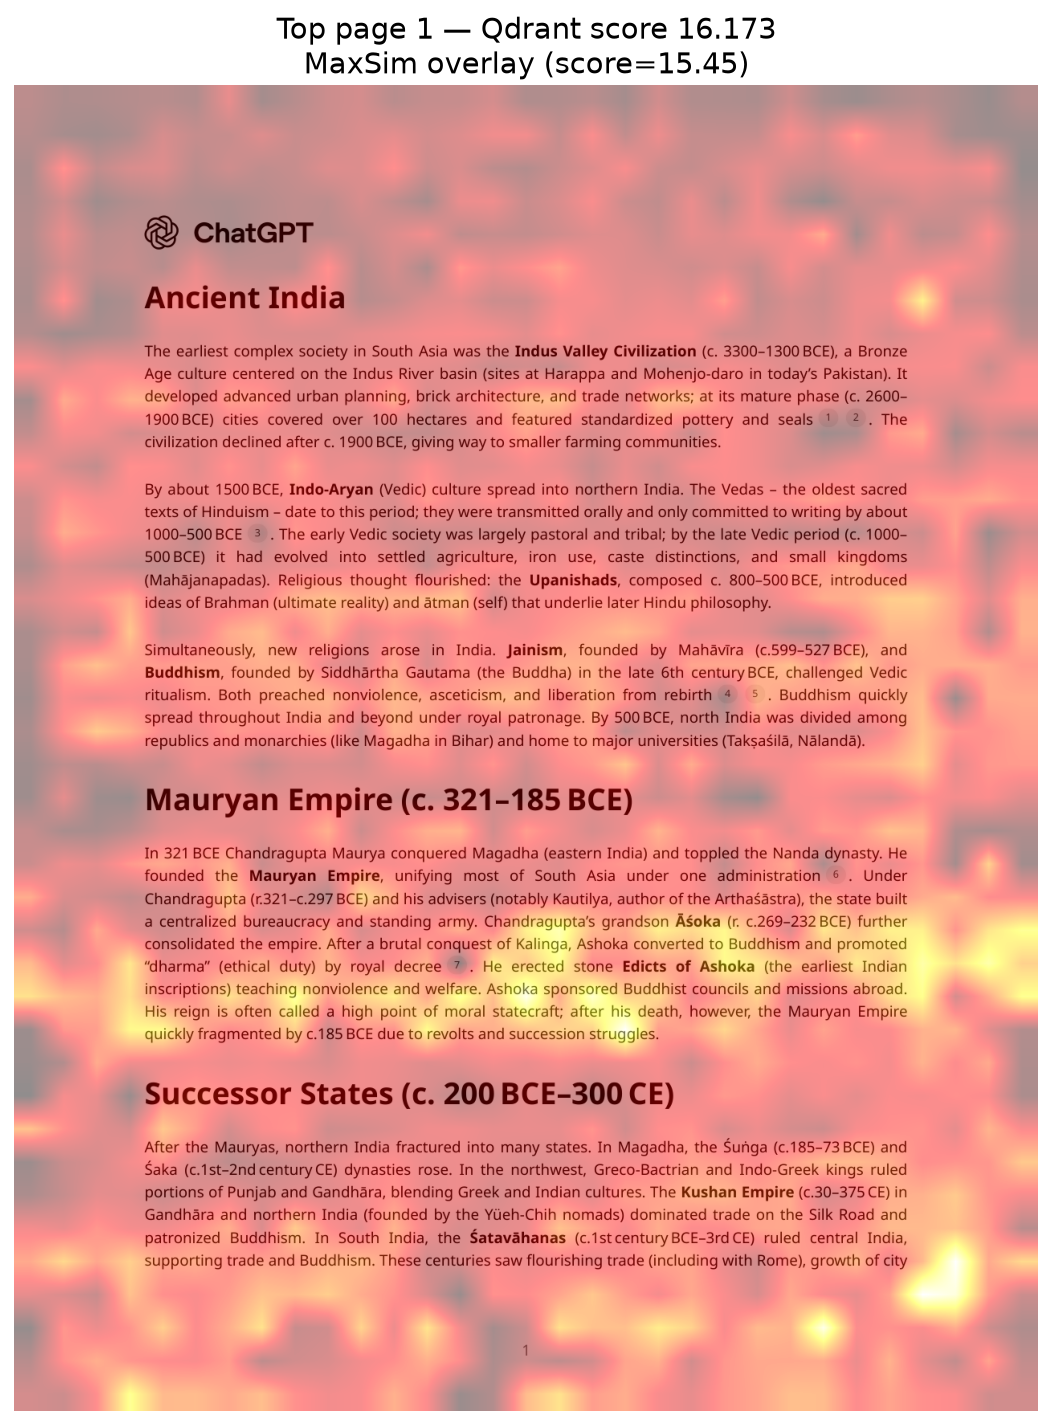

In [8]:
top_hit = search_results[0]
top_page_idx = top_hit.id
top_page_vectors = page_embeddings[top_page_idx]
top_image_path = top_hit.payload["image_path"]

viz = prepare_maxsim_visualization(
  image_path=top_image_path,
  query_vectors=query_embedding,
  page_vectors=top_page_vectors,
)

plot_page_overlay(
  viz,
  title=(
    f"Top page {top_hit.payload['page_number']} — "
    f"Qdrant score {top_hit.score:.3f}"
  ),
)

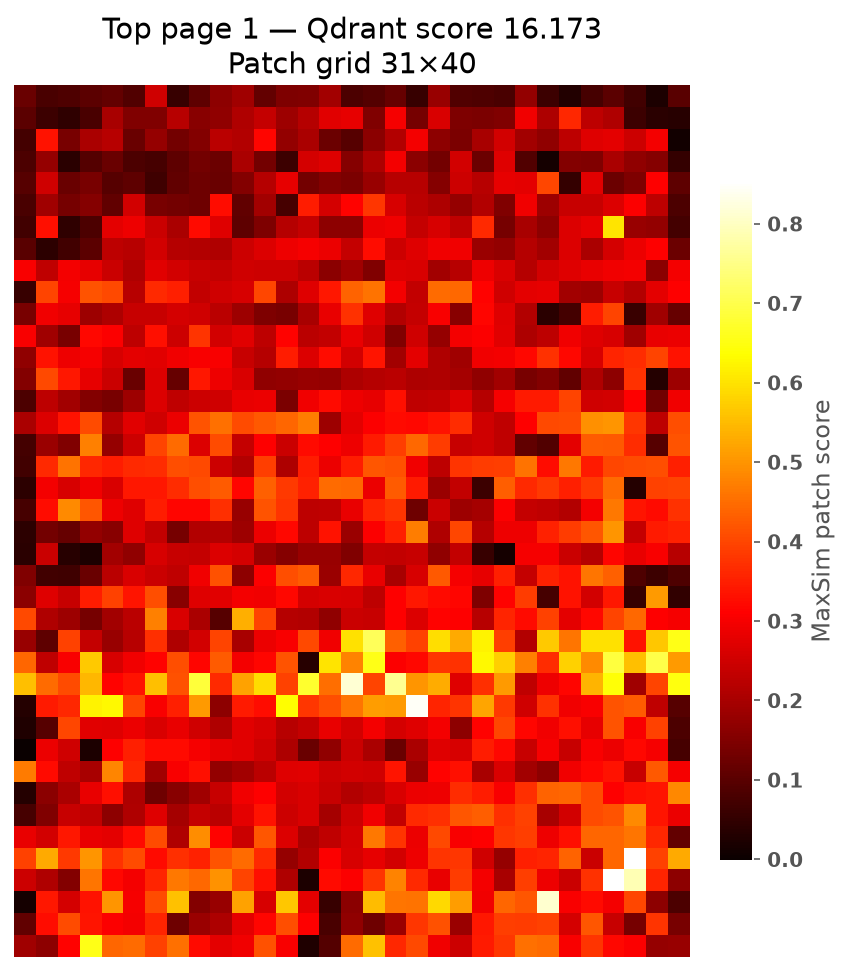

Visual patch grid: 31×40 (1240 patches, 11 prompt tokens skipped)
Query-token → best visual-patch indices: [261, 801, 851, 852, 1113, 854, 871, 1143, 864, 885, 1113, 790] …


In [9]:
plot_heatmap_scale(
  viz,
  title=(
    f"Top page {top_hit.payload['page_number']} — "
    f"Qdrant score {top_hit.score:.3f}"
  ),
)

### Try a few more queries

Change `QUERY` below and re-run the cells through the overlay and patch-grid scale plots.

Embedded items 0–0
#1  page 1  score=12.700
#2  page 6  score=9.158
#3  page 3  score=8.651


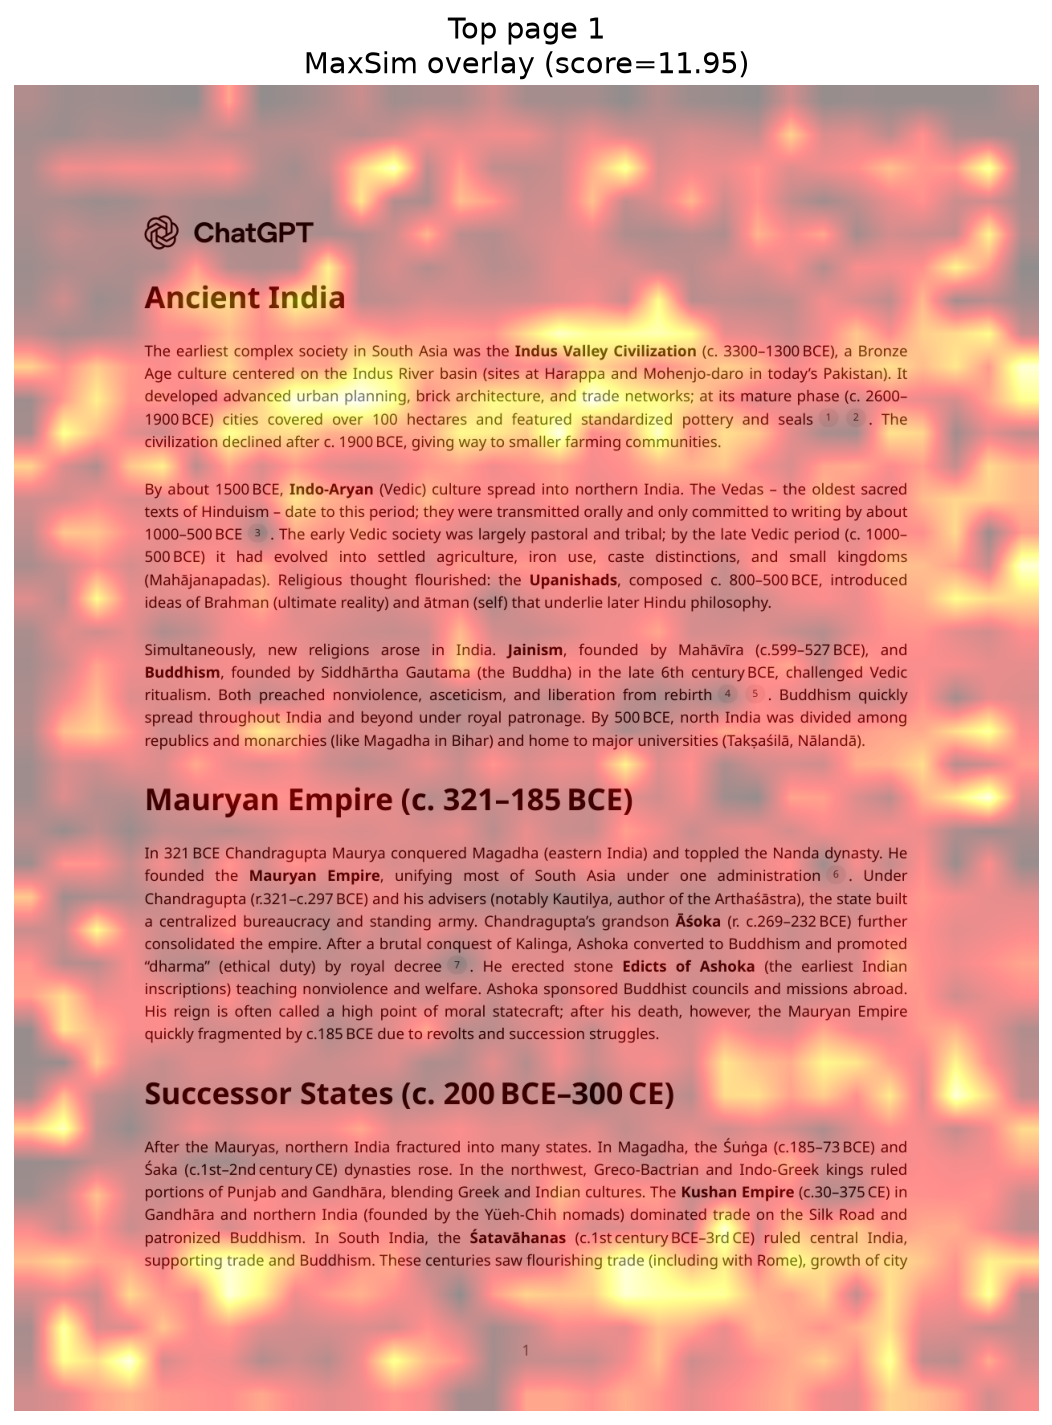

In [10]:
QUERY = "Indus Valley Civilization urban planning and trade"

query_embedding = embed_colpali_query(QUERY)
search_results = qdrant.query_points(
  collection_name=COLLECTION_NAME,
  query=query_embedding,
  limit=3,
  with_payload=True,
).points

for rank, hit in enumerate(search_results, start=1):
  print(f"#{rank}  page {hit.payload['page_number']}  score={hit.score:.3f}")

top_hit = search_results[0]
viz = prepare_maxsim_visualization(
  image_path=top_hit.payload["image_path"],
  query_vectors=query_embedding,
  page_vectors=page_embeddings[top_hit.id],
)
plot_page_overlay(viz, title=f"Top page {top_hit.payload['page_number']}")

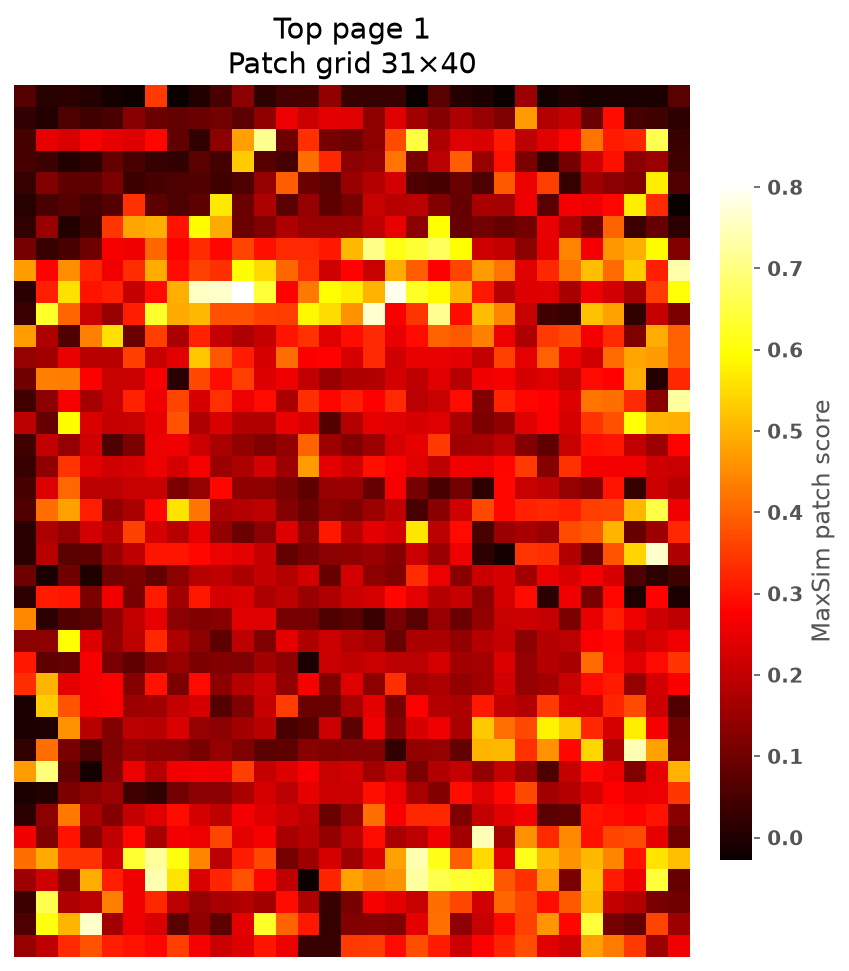

Visual patch grid: 31×40 (1240 patches, 11 prompt tokens skipped)
Query-token → best visual-patch indices: [224, 73, 91, 1181, 288, 289, 289, 296, 1145, 1145, 1145, 1204] …


In [11]:
plot_heatmap_scale(viz, title=f"Top page {top_hit.payload['page_number']}")

Embedded items 0–0
#1  page 4  score=13.651
#2  page 2  score=9.889
#3  page 1  score=9.533


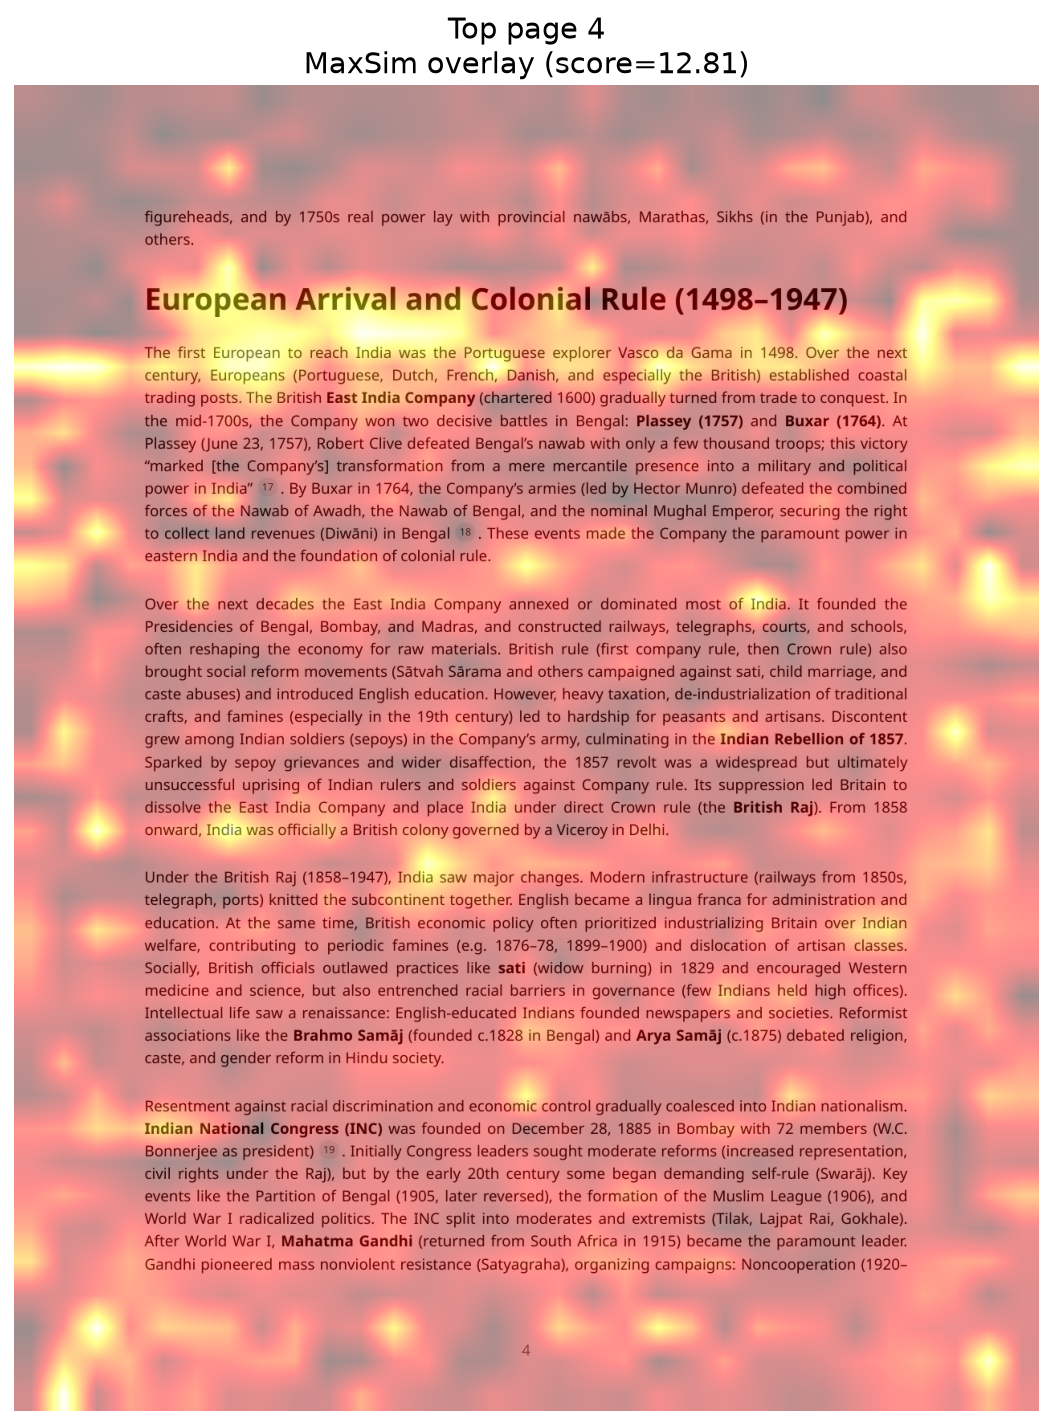

In [12]:
QUERY = "When did Europeans first arrive in India?"

query_embedding = embed_colpali_query(QUERY)
search_results = qdrant.query_points(
  collection_name=COLLECTION_NAME,
  query=query_embedding,
  limit=3,
  with_payload=True,
).points

for rank, hit in enumerate(search_results, start=1):
  print(f"#{rank}  page {hit.payload['page_number']}  score={hit.score:.3f}")

top_hit = search_results[0]
viz = prepare_maxsim_visualization(
  image_path=top_hit.payload["image_path"],
  query_vectors=query_embedding,
  page_vectors=page_embeddings[top_hit.id],
)
plot_page_overlay(viz, title=f"Top page {top_hit.payload['page_number']}")